In [38]:
#Required Libaries
import time
import matplotlib.pyplot as plt
import numpy as np

In [39]:
#Creates an array of size n
def createArray(n):
    return list(np.random.randint(100, size = n))

def createTestData():
    testData = []
    for i in range(0, 100):
        testData.append(createArray(i))
    return testData

In [40]:
#Insert sort implementation
def InsertionSort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i-1
        #If the checkeed element is greater than the key then we move those array elements to one position ahead
        while j>=0 and key<arr[j]: 
            arr[j+1] = arr[j]
            j -= 1
        arr[j+1] = key
    return arr

def TimeInsertionSort(arr):
    start = time.perf_counter()
    InsertionSort(arr)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1

In [41]:
#Quick sort Implementation
def swap(arr, i, j):
    arr[i], arr[j] = arr[j], arr[i]

def partition(arr, low, high):
    # Choosing the piviot 
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] < pivot:
            i += 1
            swap(arr, i, j)
    swap(arr, i + 1, high)
    return i + 1

def QuickSort(arr, low, high):
    if low < high:
        pi = partition(arr, low, high)
        QuickSort(arr, low, pi - 1)
        QuickSort(arr, pi + 1, high)

def TimeQuickSort(arr):
    start = time.perf_counter()
    QuickSort(arr, 0, len(arr) -1)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1
 

In [42]:
def HybridSort(arr, k):
    if(len(arr) <= k):
        InsertionSort(arr)
    else:
        QuickSort(arr, 0, len(arr) -1)

def TimeHybridSort(arr, k):
    start = time.perf_counter()
    HybridSort(arr, k)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1

In [43]:
def TestCorrectness(arr):
    buffer_array = arr
    buffer_array.sort()
    return arr == buffer_array

In [ ]:
def testValue(k):
    testData = createTestData()
    insertionData = []
    quickData = []
    testDataLength = []
    hybridData = []
    #Collecting data for the time it takes to perform quick sort and insertion sort on the arrays created of different sizes.
    for testArray in testData:
        testDataLength.append(len(testArray))
        #We pass copies of the array so that each algorithm deals with the original unsorted array
        quickData.append(TimeQuickSort(testArray.copy()))
        insertionData.append(TimeInsertionSort(testArray.copy()))
    #If there is a -1 in the data, that means that the data for insertion or quick sort failed to pass the correctness test
    if(-1 in insertionData or -1 in quickData):
        print("One of the arrays were not sorted correctly.")
        return 1
    fig = plt.figure()
    fig, ax = plt.subplots(layout = "constrained")
    testDataLength = np.array(testDataLength)
    a, b = np.polyfit(testDataLength, insertionData, 1)
    c, d = np.polyfit(testDataLength, quickData, 1)
    for testArray in testData:
        hybridData.append(TimeHybridSort(testArray, k))
    e, f = np.polyfit(testDataLength, hybridData, 1)
    #ax.scatter(testDataLength, insertionData)
    #ax.scatter(testDataLength, quickData)
    ax.plot(testDataLength, a*testDataLength+b, label = "Insertion Sort")
    ax.plot(testDataLength, c*testDataLength+d, label = "Quick Sort")
    ax.plot(testDataLength, e*testDataLength+f, label = "Hybrid Sort")
    #Naming the graph and axes of the graph
    ax.set_title(f"Time to sort vs Size of array. K value for Hybrid Sort is {k}")
    ax.set_ylabel("Time")
    ax.set_xlabel("Size of array")
    ax.legend()

<Figure size 640x480 with 0 Axes>

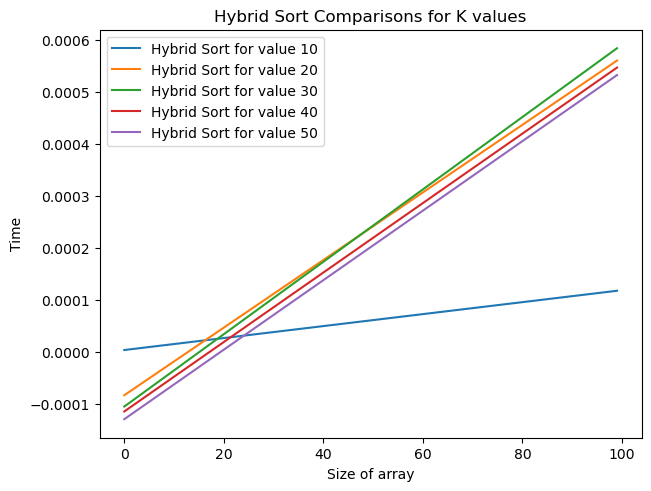

In [50]:
def main():
    testData = createTestData()
    testDataLength = []
    hybridData10 = []
    hybridData20 = []
    hybridData30 = []
    hybridData40 = []
    hybridData50 = []
    for testArray in testData:
        testDataLength.append(len(testArray))
        hybridData10.append(TimeHybridSort(testArray, 10))
        hybridData20.append(TimeHybridSort(testArray, 20))
        hybridData30.append(TimeHybridSort(testArray, 30))
        hybridData40.append(TimeHybridSort(testArray, 40))
        hybridData50.append(TimeHybridSort(testArray, 50))
    fig = plt.figure()
    fig, ax = plt.subplots(layout = "constrained")
    testDataLength = np.array(testDataLength)
    a, b = np.polyfit(testDataLength, hybridData10, 1)
    c, d = np.polyfit(testDataLength, hybridData20, 1)
    e, f = np.polyfit(testDataLength, hybridData30, 1)
    g, h = np.polyfit(testDataLength, hybridData40, 1)
    i, j = np.polyfit(testDataLength, hybridData50, 1)
    ax.plot(testDataLength, a*testDataLength+b, label = "Hybrid Sort for value 10")
    ax.plot(testDataLength, c*testDataLength+d, label = "Hybrid Sort for value 20")
    ax.plot(testDataLength, e*testDataLength+f, label = "Hybrid Sort for value 30")
    ax.plot(testDataLength, g*testDataLength+h, label = "Hybrid Sort for value 40")
    ax.plot(testDataLength, i*testDataLength+j, label = "Hybrid Sort for value 50")
    #Naming the graph and axes of the graph
    ax.set_title(f"Hybrid Sort Comparisons for K values")
    ax.set_ylabel("Time")
    ax.set_xlabel("Size of array")
    ax.legend()

main()

<Figure size 640x480 with 0 Axes>

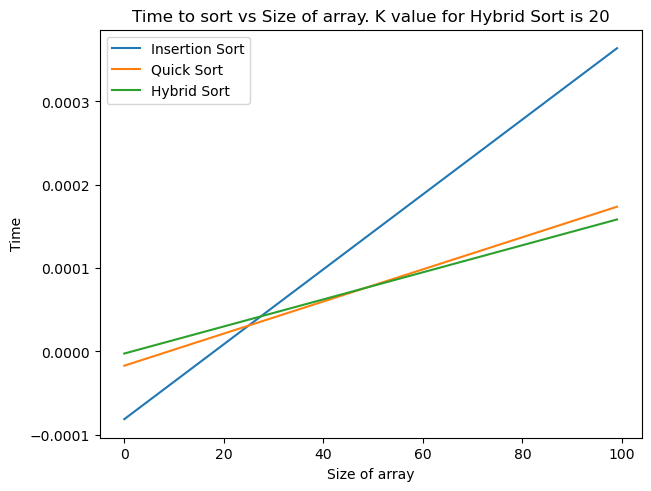

In [45]:
testValue(20)

From this graph we can see that using 20 as the K value produces sorting times that are intially longer than insertion sort, but then out-performs insertion sort as the sizes of the arrays get longer. The hybrid sort method also strictly out performs the quick sort method with the K value of 25.

<Figure size 640x480 with 0 Axes>

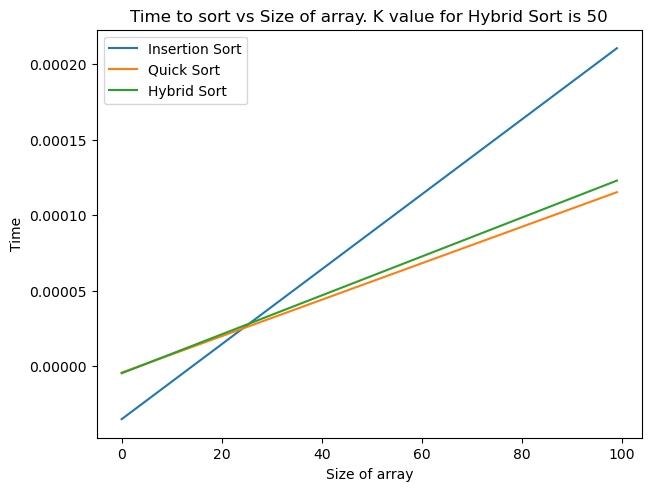

In [46]:
testValue(50)

<Figure size 640x480 with 0 Axes>

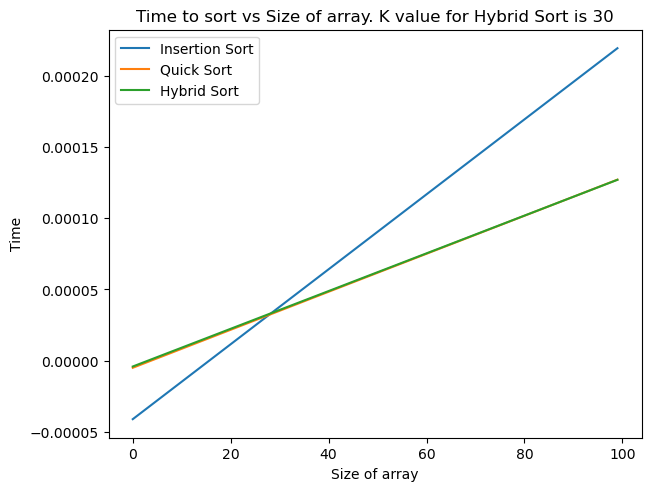

In [47]:
testValue(30)

<Figure size 640x480 with 0 Axes>

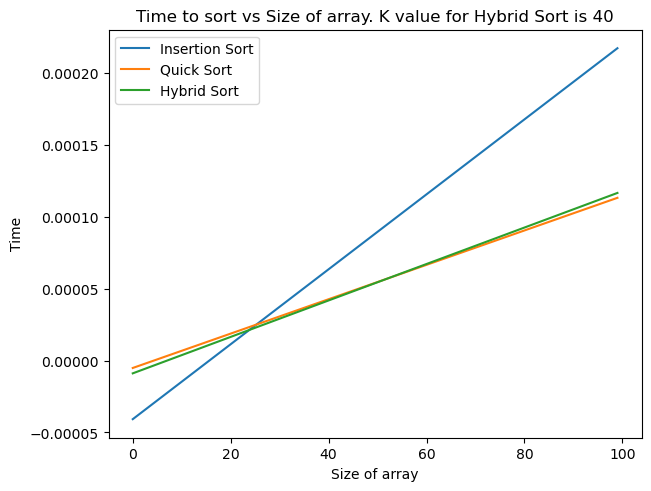

In [48]:
testValue(40)

<Figure size 640x480 with 0 Axes>

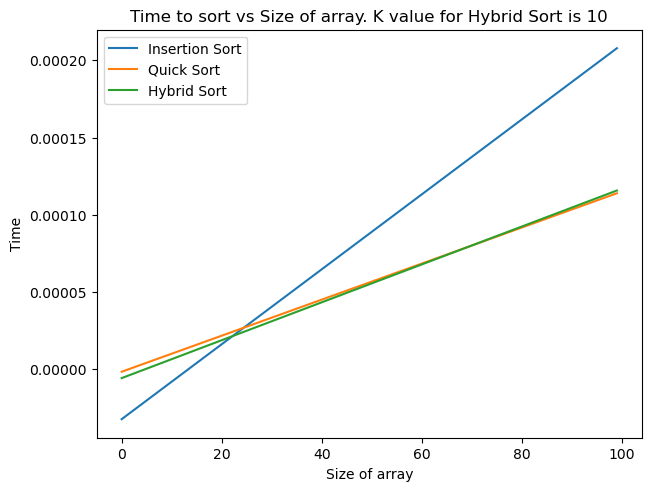

In [49]:
testValue(10)